In [22]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

print("pandas version:", pd.__version__)


BASE = Path(r"C:\Smart Energy management\wh")


dataMEC03 = pd.read_csv(BASE / "MEC03.20250720T200752.csv")
dataRes   = pd.read_csv(BASE / "Res-final-energy.csv")
dataCO2   = pd.read_csv(BASE / "Res-CO2-emissions.csv")
datadwelling = pd.read_csv(BASE / "Energy-per-dwelling.csv")
datafuel  = pd.read_csv(BASE / "Res-final-energy-by-fuel (1).csv")


for df in [dataMEC03, dataRes, dataCO2, datadwelling, datafuel]:
    df.columns = df.columns.str.strip()


def quick_qc(df, name):
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values (top 5):")
    print(df.isna().sum().sort_values(ascending=False).head(5))

quick_qc(dataMEC03, "MEC03")
quick_qc(dataRes, "Res-final-energy")
quick_qc(dataCO2, "Res-CO2-emissions")
quick_qc(datadwelling, "Energy-per-dwelling")
quick_qc(datafuel, "Res-final-energy-by-fuel")


pandas version: 2.3.1

MEC03
Shape: (1500, 6)
Columns: ['Year', 'Statistic Label', 'Counties & Dublin Postal Districts', 'Sector', 'UNIT', 'VALUE']
Missing values (top 5):
Year                                  1000
Statistic Label                          0
Counties & Dublin Postal Districts       0
Sector                                   0
UNIT                                     0
dtype: int64

Res-final-energy
Shape: (18, 3)
Columns: ['Residential Final Energy (ktoe)', 'Residential Final Energy Demand', 'Weather Corrected Residential Final Energy Demand']
Missing values (top 5):
Residential Final Energy (ktoe)                      0
Residential Final Energy Demand                      0
Weather Corrected Residential Final Energy Demand    0
dtype: int64

Res-CO2-emissions
Shape: (18, 6)
Columns: ['Residential Carbon Emissions (ktCO2)', 'Coal', 'Peat', 'Oil', 'Natural Gas', 'Electricity']
Missing values (top 5):
Residential Carbon Emissions (ktCO2)    0
Coal                         

In [ ]:


def standardize_year_first_col(df, name):
    df = df.copy()

    
    first_col = df.columns[0]
    df.rename(columns={first_col: "year"}, inplace=True)

    
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df.dropna(subset=["year"])
    df["year"] = df["year"].astype(int)

    
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print(f"{name}: years {df['year'].min()}–{df['year'].max()}, shape={df.shape}")
    return df


dataRes = standardize_year_first_col(dataRes, "dataRes")
dataCO2 = standardize_year_first_col(dataCO2, "dataCO2")
datadwelling = standardize_year_first_col(datadwelling, "datadwelling")
datafuel = standardize_year_first_col(datafuel, "datafuel")

display(dataRes.head())


dataRes: years 2005–2022, shape=(18, 3)
dataCO2: years 2005–2022, shape=(18, 6)
datadwelling: years 2005–2022, shape=(18, 4)
datafuel: years 2005–2022, shape=(18, 7)


,year,Residential Final Energy Demand,Weather Corrected Residential Final Energy Demand
0,2005,3295.927600,3362.937299
1,2006,3319.383882,3425.475232
2,2007,3269.668743,3459.465957
3,2008,3580.419570,3443.511615
4,2009,3481.179493,3343.102052


In [24]:
print("MEC03 Columns:", dataMEC03.columns.tolist())
print("Res-final-energy columns:", dataRes.columns.tolist())
print("CO2 emissions columns:", dataCO2.columns.tolist())
print("Energy per dwelling columns:", datadwelling.columns.tolist())
print("Energy by fuel columns:", datafuel.columns.tolist())


MEC03 Columns: ['Year', 'Statistic Label', 'Counties & Dublin Postal Districts', 'Sector', 'UNIT', 'VALUE']
Res-final-energy columns: ['year', 'Residential Final Energy Demand', 'Weather Corrected Residential Final Energy Demand']
CO2 emissions columns: ['year', 'Coal', 'Peat', 'Oil', 'Natural Gas', 'Electricity']
Energy per dwelling columns: ['year', 'Non-electric energy', 'Non-electric (Weather corrected)', 'Electricity']
Energy by fuel columns: ['year', 'Coal', 'Peat', 'Oil', 'Natural Gas', 'Renewables', 'Electricity']


In [25]:
for name, df in {
    "dataRes": dataRes,
    "dataCO2": dataCO2,
    "datadwelling": datadwelling,
    "datafuel": datafuel
}.items():
    print(f"\n{name}: year dtype={df['year'].dtype}, range={df['year'].min()}–{df['year'].max()}")



dataRes: year dtype=int64, range=2005–2022

dataCO2: year dtype=int64, range=2005–2022

datadwelling: year dtype=int64, range=2005–2022

datafuel: year dtype=int64, range=2005–2022


In [ ]:
from IPython.display import display, HTML

def show_table(df, title, year_col=None):
    display(HTML(f"<h3>{title}</h3>"))
    display(df.head())
    print("Shape:", df.shape)
    if year_col and year_col in df.columns:
        print("Year range:", df[year_col].min(), "to", df[year_col].max())
    print("-" * 60)


try:
    show_table(dataMEC03_clean, "MEC03 Dataset (Electricity Consumption)", year_col="Year")
except NameError:
    show_table(dataMEC03, "MEC03 Dataset (Electricity Consumption)", year_col="Year")

show_table(dataRes, "Residential Final Energy Demand", year_col="year")
show_table(dataCO2, "Residential CO2 Emissions by Fuel", year_col="year")
show_table(datadwelling, "Energy Intensity per Dwelling", year_col="year")
show_table(datafuel, "Residential Final Energy by Fuel", year_col="year")


,Year,Statistic Label,Counties & Dublin Postal Districts,Sector,UNIT,VALUE
0,2015.0,Metered Electricity Consumption,All Counties and Dublin Postal Districts,All sectors,Gigawatt Hours,24600
1,2015.0,Metered Electricity Consumption,All Counties and Dublin Postal Districts,10 Residential,Gigawatt Hours,8370
2,2015.0,Metered Electricity Consumption,All Counties and Dublin Postal Districts,20 Non-residential,Gigawatt Hours,16230
3,2015.0,Metered Electricity Consumption,Not coded,All sectors,Gigawatt Hours,2943
4,2015.0,Metered Electricity Consumption,Not coded,10 Residential,Gigawatt Hours,2


Shape: (1500, 6)
Year range: 2015.0 to 2024.0
------------------------------------------------------------


,year,Residential Final Energy Demand,Weather Corrected Residential Final Energy Demand
0,2005,3295.927600,3362.937299
1,2006,3319.383882,3425.475232
2,2007,3269.668743,3459.465957
3,2008,3580.419570,3443.511615
4,2009,3481.179493,3343.102052


Shape: (18, 3)
Year range: 2005 to 2022
------------------------------------------------------------


,year,Coal,Peat,Oil,Natural Gas,Electricity
0,2005,989,1170,4564,1443,4775
1,2006,877,1216,4439,1504,4819
2,2007,835,1163,4458,1414,4523
3,2008,922,1195,4951,1593,4671
4,2009,1070,1161,4763,1492,4260


Shape: (18, 6)
Year range: 2005 to 2022
------------------------------------------------------------


,year,Non-electric energy,Non-electric (Weather corrected),Electricity
0,2005,21755,22286,5303
1,2006,20871,21683,5528
2,2007,19978,21395,5377
3,2008,21542,20547,5547
4,2009,20553,19572,5160


Shape: (18, 4)
Year range: 2005 to 2022
------------------------------------------------------------


,year,Coal,Peat,Oil,Natural Gas,Renewables,Electricity
0,2005,252,280,1541,622,20,648
1,2006,227,295,1525,657,23,699
2,2007,223,291,1577,635,34,701
3,2008,219,267,1561,638,31,728
4,2009,254,259,1503,595,39,693


Shape: (18, 7)
Year range: 2005 to 2022
------------------------------------------------------------


In [78]:
# Objective 1 / RQ1: energy consumption trends (Residential sector)


try:
    mec = dataMEC03_clean.copy()
except NameError:
    mec = dataMEC03.copy()


mec["Sector"] = mec["Sector"].astype(str).str.strip()
mec["Counties & Dublin Postal Districts"] = mec["Counties & Dublin Postal Districts"].astype(str).str.strip()


residential_MEC03 = mec[mec["Sector"].str.contains("Residential", case=False, na=False)].copy()


residential_MEC03 = residential_MEC03[
    ~residential_MEC03["Counties & Dublin Postal Districts"].str.contains("Not coded|Not stated|Unknown", case=False, na=False)
].copy()

print(residential_MEC03.head())
print("Rows:", residential_MEC03.shape[0], "| Years:", residential_MEC03["Year"].min(), "-", residential_MEC03["Year"].max())


      Year                  Statistic Label  \
1   2015.0  Metered Electricity Consumption   
2   2015.0  Metered Electricity Consumption   
7   2015.0  Metered Electricity Consumption   
8   2015.0  Metered Electricity Consumption   
10  2015.0  Metered Electricity Consumption   

          Counties & Dublin Postal Districts              Sector  \
1   All Counties and Dublin Postal Districts      10 Residential   
2   All Counties and Dublin Postal Districts  20 Non-residential   
7                                  Co. Clare      10 Residential   
8                                  Co. Clare  20 Non-residential   
10                                  Co. Cork      10 Residential   

              UNIT  VALUE  
1   Gigawatt Hours   8370  
2   Gigawatt Hours  16230  
7   Gigawatt Hours    205  
8   Gigawatt Hours    321  
10  Gigawatt Hours   1001  
Rows: 980 | Years: 2015.0 - 2024.0


In [28]:
display(dataRes.head())
print("Shape:", dataRes.shape)
print("Year range:", dataRes["year"].min(), "to", dataRes["year"].max())
print("Dtypes:\n", dataRes.dtypes)


,year,Residential Final Energy Demand,Weather Corrected Residential Final Energy Demand
0,2005,3295.927600,3362.937299
1,2006,3319.383882,3425.475232
2,2007,3269.668743,3459.465957
3,2008,3580.419570,3443.511615
4,2009,3481.179493,3343.102052


Shape: (18, 3)
Year range: 2005 to 2022
Dtypes:
 year                                                   int64
Residential Final Energy Demand                      float64
Weather Corrected Residential Final Energy Demand    float64
dtype: object


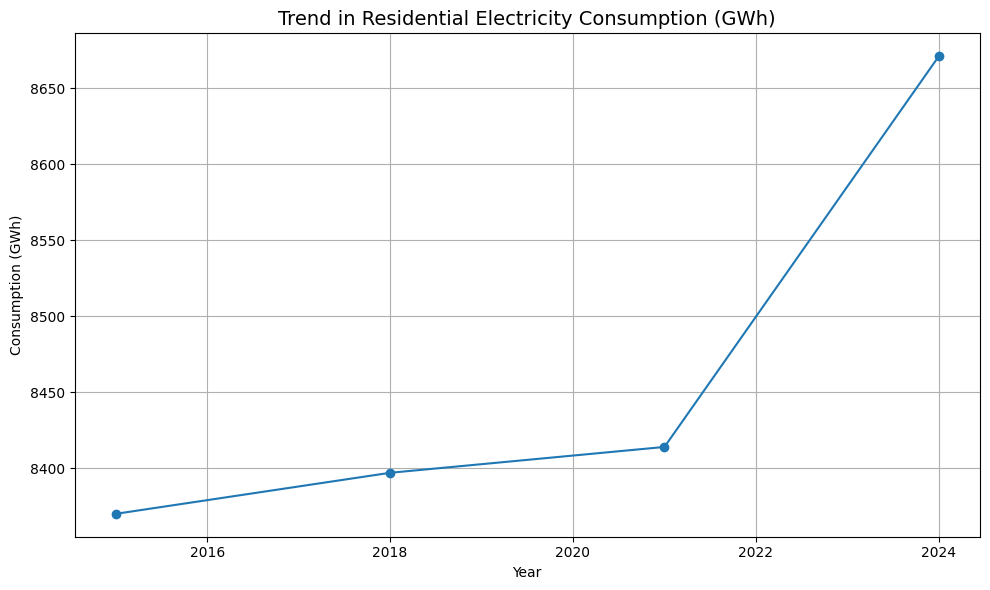

In [ ]:
import matplotlib.pyplot as plt


yearly_residential = residential_MEC03[
    residential_MEC03["Counties & Dublin Postal Districts"]
    .astype(str)
    .str.contains("All Counties and Dublin Postal Districts", case=False, na=False)
].copy()


yearly_residential["Year"] = pd.to_numeric(yearly_residential["Year"], errors="coerce")
yearly_residential["VALUE"] = pd.to_numeric(yearly_residential["VALUE"], errors="coerce")


yearly_residential = (
    yearly_residential
    .dropna(subset=["Year", "VALUE"])
    .groupby("Year", as_index=False)["VALUE"].first()
    .sort_values("Year")
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_residential["Year"].astype(int), yearly_residential["VALUE"], marker="o")
plt.title("Trend in Residential Electricity Consumption (GWh)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Consumption (GWh)")
plt.grid(True)
plt.tight_layout()
plt.show()



C:\Users\91994\AppData\Local\Temp\ipykernel_15948\808504544.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_regions, x='VALUE', y='Cleaned Region', palette='Blues_d')


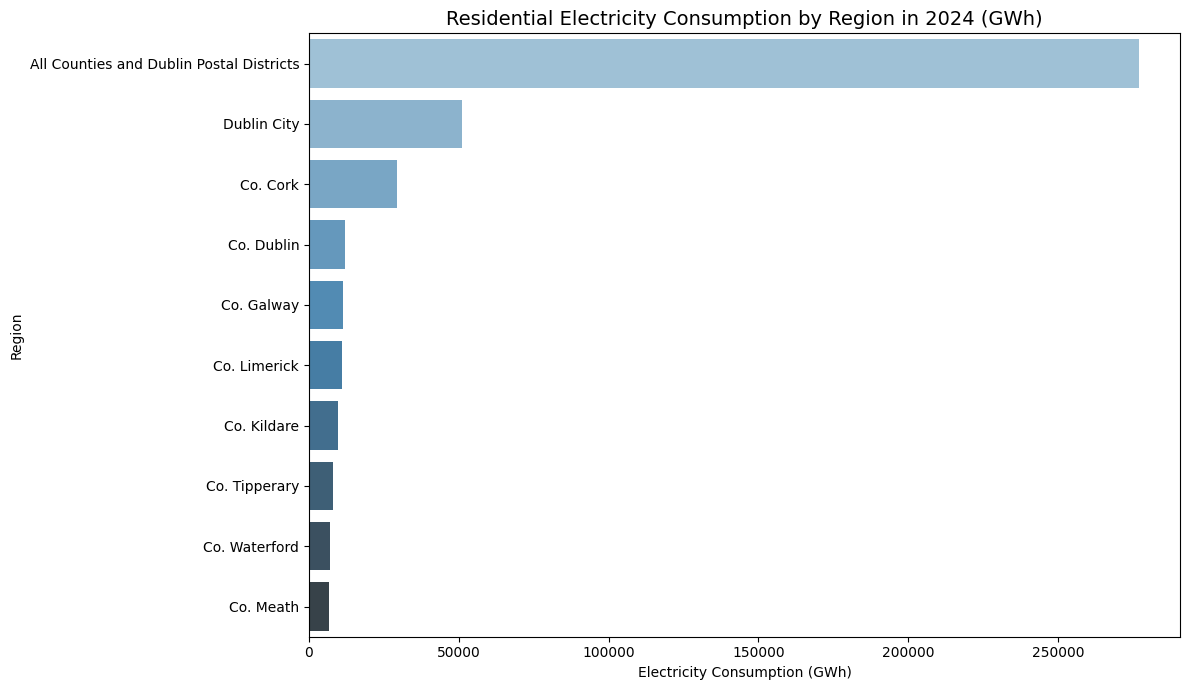

In [79]:

regional_latest_cleaned = residential_MEC03[~residential_MEC03['Counties & Dublin Postal Districts'].str.contains('Not coded', na=False)].copy()


import re
def group_region(region):
    if re.match(r'^Dublin\s?\d{1,2}[A-Za-z]?$', region):
        return 'Dublin City'
    else:
        return region


regional_latest_cleaned['Cleaned Region'] = regional_latest_cleaned['Counties & Dublin Postal Districts'].apply(group_region)


latest_year = regional_latest_cleaned['Year'].max()


regional_grouped = regional_latest_cleaned.groupby('Cleaned Region', as_index=False)['VALUE'].sum()


regional_grouped_sorted = regional_grouped.sort_values(by='VALUE', ascending=False)


top10_regions = regional_grouped_sorted.head(10)

# Visualize top 10 regions
plt.figure(figsize=(12,7))
sns.barplot(data=top10_regions, x='VALUE', y='Cleaned Region', palette='Blues_d')
plt.title(f'Residential Electricity Consumption by Region in {int(latest_year)} (GWh)', fontsize=14)
plt.xlabel('Electricity Consumption (GWh)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


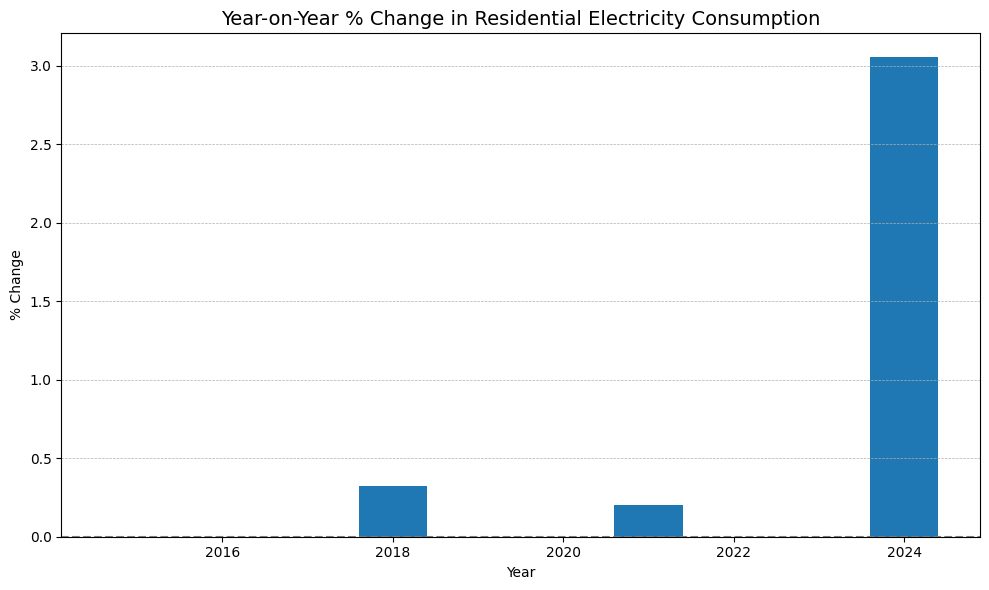

In [80]:

yearly_residential = yearly_residential.sort_values("Year").reset_index(drop=True)
yearly_residential["% Change"] = yearly_residential["VALUE"].pct_change() * 100
yearly_residential["% Change"] = yearly_residential["% Change"].fillna(0)


plt.figure(figsize=(10, 6))
plt.bar(yearly_residential["Year"].astype(int), yearly_residential["% Change"])
plt.axhline(0, color="gray", linestyle="--")
plt.title("Year-on-Year % Change in Residential Electricity Consumption", fontsize=14)
plt.xlabel("Year")
plt.ylabel("% Change")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


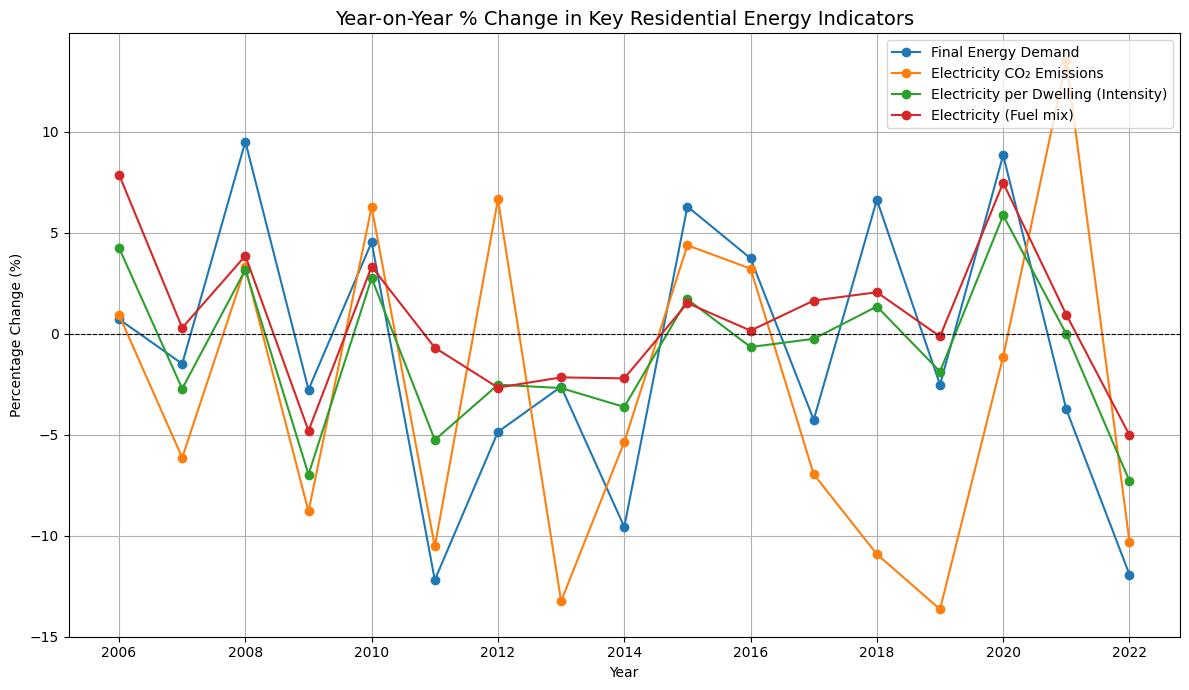

,year,pct_final_energy,pct_co2_elec,pct_intensity,pct_fuel_elec
0,2006,0.711675,0.921466,4.242881,7.870370
1,2007,-1.497722,-6.142353,-2.731548,0.286123
2,2008,9.504046,3.272164,3.161614,3.851641
3,2009,-2.771744,-8.798972,-6.976744,-4.807692
4,2010,4.526386,6.267606,2.751938,3.318903


In [81]:
import numpy as np
import matplotlib.pyplot as plt


dataRes = dataRes.sort_values("year").reset_index(drop=True)
dataCO2 = dataCO2.sort_values("year").reset_index(drop=True)
datadwelling = datadwelling.sort_values("year").reset_index(drop=True)
datafuel = datafuel.sort_values("year").reset_index(drop=True)


dataRes["Residential Final Energy Demand"] = pd.to_numeric(dataRes["Residential Final Energy Demand"], errors="coerce")
dataCO2["Electricity"] = pd.to_numeric(dataCO2["Electricity"], errors="coerce")
datadwelling["Electricity"] = pd.to_numeric(datadwelling["Electricity"], errors="coerce")
datafuel["Electricity"] = pd.to_numeric(datafuel["Electricity"], errors="coerce")


dataRes["pct_final_energy"] = dataRes["Residential Final Energy Demand"].pct_change() * 100
dataCO2["pct_co2_elec"] = dataCO2["Electricity"].pct_change() * 100
datadwelling["pct_intensity"] = datadwelling["Electricity"].pct_change() * 100
datafuel["pct_fuel_elec"] = datafuel["Electricity"].pct_change() * 100


merged_pct = (
    dataRes[["year", "pct_final_energy"]]
    .merge(dataCO2[["year", "pct_co2_elec"]], on="year", how="inner")
    .merge(datadwelling[["year", "pct_intensity"]], on="year", how="inner")
    .merge(datafuel[["year", "pct_fuel_elec"]], on="year", how="inner")
)


merged_pct = merged_pct.dropna().reset_index(drop=True)

# --- Plot (matplotlib) ---
plt.figure(figsize=(12, 7))
plt.plot(merged_pct["year"], merged_pct["pct_final_energy"], marker="o", label="Final Energy Demand")
plt.plot(merged_pct["year"], merged_pct["pct_co2_elec"], marker="o", label="Electricity CO₂ Emissions")
plt.plot(merged_pct["year"], merged_pct["pct_intensity"], marker="o", label="Electricity per Dwelling (Intensity)")
plt.plot(merged_pct["year"], merged_pct["pct_fuel_elec"], marker="o", label="Electricity (Fuel mix)")

plt.title("Year-on-Year % Change in Key Residential Energy Indicators", fontsize=14)
plt.ylabel("Percentage Change (%)")
plt.xlabel("Year")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(merged_pct.head())


In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib
from pathlib import Path


In [82]:

from pathlib import Path




household_files = [
    "H1_Wh.csv",
    "H2_Wh.csv",
    "H3_Wh.csv",
    "H4_Wh.csv",
    "H6_Wh.csv",
    "H8_Wh.csv",
    "H10_Wh.csv",
    "H13_Wh.csv",
    "H15_Wh.csv",
    "H11_Wh.csv",
    
]

dfs = []
for f in household_files:
    df = pd.read_csv(BASE / f, parse_dates=["date"])
    df.columns = df.columns.str.strip()  
    df["household"] = f.replace(".csv", "")  
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)


combined_df.columns = combined_df.columns.str.strip()
CONS_COL = "Consumption(Wh)"  


combined_df[CONS_COL] = pd.to_numeric(combined_df[CONS_COL], errors="coerce").fillna(0)
combined_df[CONS_COL] = combined_df[CONS_COL].clip(lower=0)


combined_df["day"] = combined_df["date"].dt.date


daily_summary = combined_df.groupby(["household", "day"])[CONS_COL].sum().reset_index()

print("Households loaded:", combined_df["household"].nunique())
print("Unique households:", combined_df["household"].unique())
print(daily_summary.head())


Households loaded: 10
Unique households: ['H1_Wh' 'H2_Wh' 'H3_Wh' 'H4_Wh' 'H6_Wh' 'H8_Wh' 'H10_Wh' 'H13_Wh'
 'H15_Wh' 'H11_Wh']
  household         day  Consumption(Wh)
0    H10_Wh  2020-01-01        22855.650
1    H10_Wh  2020-01-02        29894.860
2    H10_Wh  2020-01-03        34958.815
3    H10_Wh  2020-01-04        30541.735
4    H10_Wh  2020-01-05            0.000


In [41]:
# Sanity checks
print("Rows:", combined_df.shape[0])
print("Date range:", combined_df["date"].min(), "to", combined_df["date"].max())
print("Missing consumption:", combined_df[CONS_COL].isna().sum())


Rows: 5270330
Date range: 2020-01-01 01:01:00 to 2021-01-01 00:59:00
Missing consumption: 0


In [42]:
combined_df["hour"] = combined_df["date"].dt.hour
combined_df["weekday"] = combined_df["date"].dt.weekday
combined_df["is_weekend"] = (combined_df["weekday"] >= 5).astype(int)
combined_df["day"] = combined_df["date"].dt.date

combined_df[["date", "hour", "weekday", "is_weekend", "day"]].head()


,date,hour,weekday,is_weekend,day
0,2020-01-01 01:01:00,1,2,0,2020-01-01
1,2020-01-01 01:02:00,1,2,0,2020-01-01
2,2020-01-01 01:03:00,1,2,0,2020-01-01
3,2020-01-01 01:04:00,1,2,0,2020-01-01
4,2020-01-01 01:05:00,1,2,0,2020-01-01


In [43]:
combined_df["solar_used_Wh"] = np.minimum(combined_df["Consumption(Wh)"], combined_df["Production(Wh)"])

solar_metrics = combined_df.groupby("household").agg(
    total_consumption=("Consumption(Wh)", "sum"),
    total_production=("Production(Wh)", "sum"),
    grid_import=("From grid(Wh)", "sum"),
    solar_used=("solar_used_Wh", "sum")
).reset_index()

solar_metrics["solar_self_consumption_ratio"] = solar_metrics["solar_used"] / (solar_metrics["total_production"] + 1e-9)
solar_metrics["grid_dependency_ratio"] = solar_metrics["grid_import"] / (solar_metrics["total_consumption"] + 1e-9)

solar_metrics = solar_metrics[["household", "solar_self_consumption_ratio", "grid_dependency_ratio"]]

solar_metrics


,household,solar_self_consumption_ratio,grid_dependency_ratio
0,H10_Wh,0.474036,0.874823
1,H11_Wh,0.500939,0.826728
2,H13_Wh,0.339668,0.724336
3,H15_Wh,0.000000,1.125749
4,H1_Wh,0.211038,0.748246
5,H2_Wh,0.432583,0.763555
6,H3_Wh,0.435219,0.775158
7,H4_Wh,0.527756,0.839302
8,H6_Wh,0.000000,1.124878
9,H8_Wh,0.000000,1.111155


In [ ]:

display(combined_df.head())

print("Shape:", combined_df.shape)
print("Households:", combined_df["household"].nunique(), combined_df["household"].unique())
print("Date range:", combined_df["date"].min(), "to", combined_df["date"].max())


print("Columns:", combined_df.columns.tolist())


,date,Discharge(Wh),Charge(Wh),Production(Wh),Consumption(Wh),Feed-in(Wh),From grid(Wh),State of Charge(%),household,day,hour,weekday,is_weekend,solar_used_Wh
0,2020-01-01 01:01:00,0.0,0.13,0.0,1.58,0.0,1.71,0.0,H1_Wh,2020-01-01,1,2,0,0.0
1,2020-01-01 01:02:00,0.0,0.13,0.0,1.58,0.0,1.71,0.0,H1_Wh,2020-01-01,1,2,0,0.0
2,2020-01-01 01:03:00,0.0,0.13,0.0,1.57,0.0,1.70,0.0,H1_Wh,2020-01-01,1,2,0,0.0
3,2020-01-01 01:04:00,0.0,0.13,0.0,1.55,0.0,1.68,0.0,H1_Wh,2020-01-01,1,2,0,0.0
4,2020-01-01 01:05:00,0.0,0.13,0.0,1.55,0.0,1.68,0.0,H1_Wh,2020-01-01,1,2,0,0.0


Shape: (5270330, 14)
Households: 10 ['H1_Wh' 'H2_Wh' 'H3_Wh' 'H4_Wh' 'H6_Wh' 'H8_Wh' 'H10_Wh' 'H13_Wh'
 'H15_Wh' 'H11_Wh']
Date range: 2020-01-01 01:01:00 to 2021-01-01 00:59:00
Columns: ['date', 'Discharge(Wh)', 'Charge(Wh)', 'Production(Wh)', 'Consumption(Wh)', 'Feed-in(Wh)', 'From grid(Wh)', 'State of Charge(%)', 'household', 'day', 'hour', 'weekday', 'is_weekend', 'solar_used_Wh']


In [45]:
from pathlib import Path


output_path = BASE / "combined_household_data.csv"
combined_df.to_csv(output_path, index=False)

print("Combined household data saved to:")
print(output_path)


Combined household data saved to:
C:\Smart Energy management\wh\combined_household_data.csv


In [ ]:

# STEP 1: Behavioural feature engineering (1 row per household)



combined_df["hour"] = combined_df["date"].dt.hour
combined_df["weekday"] = combined_df["date"].dt.weekday
combined_df["is_weekend"] = (combined_df["weekday"] >= 5).astype(int)


features = combined_df.groupby("household")["Consumption(Wh)"].agg(
    total_Wh="sum",
    mean_Wh="mean",
    peak_Wh="max",
    std_Wh="std"
).reset_index()


evening = combined_df[
    (combined_df["hour"] >= 17) & (combined_df["hour"] <= 23)
].groupby("household")["Consumption(Wh)"].sum().reset_index(name="evening_Wh")

features = features.merge(evening, on="household", how="left")
features["evening_Wh"] = features["evening_Wh"].fillna(0)
features["evening_ratio"] = features["evening_Wh"] / (features["total_Wh"] + 1e-9)

# Weekend consumption
weekend = combined_df[
    combined_df["is_weekend"] == 1
].groupby("household")["Consumption(Wh)"].sum().reset_index(name="weekend_Wh")

features = features.merge(weekend, on="household", how="left")
features["weekend_Wh"] = features["weekend_Wh"].fillna(0)
features["weekend_ratio"] = features["weekend_Wh"] / (features["total_Wh"] + 1e-9)

features["std_Wh"] = features["std_Wh"].fillna(0)

display(features)


,household,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_Wh,evening_ratio,weekend_Wh,weekend_ratio
0,H10_Wh,7986097.910,15.152765,303.57,21.256653,2.332437e+06,0.292062,2199274.040,0.275388
1,H11_Wh,6095938.230,11.566389,353.53,18.114935,2.916384e+06,0.478414,1797654.410,0.294894
2,H13_Wh,2770033.190,5.255841,155.60,7.480800,6.720714e+05,0.242622,809597.015,0.292270
3,H15_Wh,5856250.100,11.111607,203.87,14.183965,2.215757e+06,0.378358,1706435.355,0.291387
4,H1_Wh,3186876.865,6.046757,258.97,16.725571,2.050339e+06,0.643369,965203.730,0.302868
5,H2_Wh,4885312.005,9.269356,181.95,13.450940,1.655061e+06,0.338783,1486748.735,0.304330
6,H3_Wh,5294813.635,10.046341,215.70,14.583438,1.585492e+06,0.299443,1527091.620,0.288413
7,H4_Wh,7875426.460,14.944479,298.73,20.855936,2.532786e+06,0.321606,2182007.540,0.277065
8,H6_Wh,6261265.275,11.880080,222.05,15.538992,3.233297e+06,0.516397,1865619.150,0.297962
9,H8_Wh,6823884.565,12.947589,176.00,17.863329,1.675877e+06,0.245590,1884206.080,0.276119


In [47]:
# Final column name cleaning + verification (run once)

combined_df.columns = combined_df.columns.str.strip()

print("Cleaned columns:")
print(combined_df.columns.tolist())


Cleaned columns:
['date', 'Discharge(Wh)', 'Charge(Wh)', 'Production(Wh)', 'Consumption(Wh)', 'Feed-in(Wh)', 'From grid(Wh)', 'State of Charge(%)', 'household', 'day', 'hour', 'weekday', 'is_weekend', 'solar_used_Wh']


In [ ]:
features = features.merge(solar_metrics, on="household", how="inner")  

features


,household,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_Wh,evening_ratio,weekend_Wh,weekend_ratio,solar_self_consumption_ratio,grid_dependency_ratio
0,H10_Wh,7986097.910,15.152765,303.57,21.256653,2.332437e+06,0.292062,2199274.040,0.275388,0.474036,0.874823
1,H11_Wh,6095938.230,11.566389,353.53,18.114935,2.916384e+06,0.478414,1797654.410,0.294894,0.500939,0.826728
2,H13_Wh,2770033.190,5.255841,155.60,7.480800,6.720714e+05,0.242622,809597.015,0.292270,0.339668,0.724336
3,H15_Wh,5856250.100,11.111607,203.87,14.183965,2.215757e+06,0.378358,1706435.355,0.291387,0.000000,1.125749
4,H1_Wh,3186876.865,6.046757,258.97,16.725571,2.050339e+06,0.643369,965203.730,0.302868,0.211038,0.748246
5,H2_Wh,4885312.005,9.269356,181.95,13.450940,1.655061e+06,0.338783,1486748.735,0.304330,0.432583,0.763555
6,H3_Wh,5294813.635,10.046341,215.70,14.583438,1.585492e+06,0.299443,1527091.620,0.288413,0.435219,0.775158
7,H4_Wh,7875426.460,14.944479,298.73,20.855936,2.532786e+06,0.321606,2182007.540,0.277065,0.527756,0.839302
8,H6_Wh,6261265.275,11.880080,222.05,15.538992,3.233297e+06,0.516397,1865619.150,0.297962,0.000000,1.124878
9,H8_Wh,6823884.565,12.947589,176.00,17.863329,1.675877e+06,0.245590,1884206.080,0.276119,0.000000,1.111155


In [49]:
FEATURE_COLS = [
    "total_Wh",
    "mean_Wh",
    "peak_Wh",
    "std_Wh",
    "evening_ratio",
    "weekend_ratio",
    "solar_self_consumption_ratio",
    "grid_dependency_ratio"
]

X = features[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (10, 8)


In [50]:
scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score

scores


{2: 0.2692269758519327,
 3: 0.36755374585028155,
 4: 0.3547856449331027,
 5: 0.37176979283920736}

In [51]:
BEST_K = max(scores, key=scores.get) if len(scores) > 0 else 3
print("Using k =", BEST_K)

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

features[["household", "cluster"] + FEATURE_COLS]


Using k = 5


,household,cluster,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_ratio,weekend_ratio,solar_self_consumption_ratio,grid_dependency_ratio
0,H10_Wh,2,7986097.910,15.152765,303.57,21.256653,0.292062,0.275388,0.474036,0.874823
1,H11_Wh,4,6095938.230,11.566389,353.53,18.114935,0.478414,0.294894,0.500939,0.826728
2,H13_Wh,1,2770033.190,5.255841,155.60,7.480800,0.242622,0.292270,0.339668,0.724336
3,H15_Wh,0,5856250.100,11.111607,203.87,14.183965,0.378358,0.291387,0.000000,1.125749
4,H1_Wh,3,3186876.865,6.046757,258.97,16.725571,0.643369,0.302868,0.211038,0.748246
5,H2_Wh,1,4885312.005,9.269356,181.95,13.450940,0.338783,0.304330,0.432583,0.763555
6,H3_Wh,1,5294813.635,10.046341,215.70,14.583438,0.299443,0.288413,0.435219,0.775158
7,H4_Wh,2,7875426.460,14.944479,298.73,20.855936,0.321606,0.277065,0.527756,0.839302
8,H6_Wh,0,6261265.275,11.880080,222.05,15.538992,0.516397,0.297962,0.000000,1.124878
9,H8_Wh,0,6823884.565,12.947589,176.00,17.863329,0.245590,0.276119,0.000000,1.111155


In [52]:
cluster_profile = features.groupby("cluster")[FEATURE_COLS].mean().round(3)
cluster_profile


,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_ratio,weekend_ratio,solar_self_consumption_ratio,grid_dependency_ratio
cluster,,,,,,,,
0,6313799.980,11.980,200.640,15.862,0.380,0.288,0.000,1.121
1,4316719.610,8.191,184.417,11.838,0.294,0.295,0.402,0.754
2,7930762.185,15.049,301.150,21.056,0.307,0.276,0.501,0.857
3,3186876.865,6.047,258.970,16.726,0.643,0.303,0.211,0.748
4,6095938.230,11.566,353.530,18.115,0.478,0.295,0.501,0.827


In [53]:
MODEL_DIR = Path("household_clustering_model")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(kmeans, MODEL_DIR / "kmeans_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(FEATURE_COLS, MODEL_DIR / "feature_columns.pkl")

print("Saved to:", MODEL_DIR.resolve())
print([p.name for p in MODEL_DIR.glob("*.pkl")])


Saved to: C:\Users\91994\OneDrive\Desktop\Smart Energy File\household_clustering_model
['feature_columns.pkl', 'kmeans_model.pkl', 'scaler.pkl']


In [ ]:

# STEP 2A: Solar production pattern feature engineering



combined_df["hour"] = combined_df["date"].dt.hour


prod_features = combined_df.groupby("household")["Production(Wh)"].agg(
    prod_total_Wh="sum",
    prod_mean_Wh="mean",
    prod_peak_Wh="max",
    prod_std_Wh="std"
).reset_index()

prod_features["prod_std_Wh"] = prod_features["prod_std_Wh"].fillna(0)


midday = combined_df[
    (combined_df["hour"] >= 11) & (combined_df["hour"] <= 15)
].groupby("household")["Production(Wh)"].sum().reset_index(name="midday_prod_Wh")

prod_features = prod_features.merge(midday, on="household", how="left")
prod_features["midday_prod_Wh"] = prod_features["midday_prod_Wh"].fillna(0)
prod_features["midday_prod_ratio"] = (
    prod_features["midday_prod_Wh"] / (prod_features["prod_total_Wh"] + 1e-9)
)

display(prod_features)


,household,prod_total_Wh,prod_mean_Wh,prod_peak_Wh,prod_std_Wh,midday_prod_Wh,midday_prod_ratio
0,H10_Wh,1929071.945,3.660207,79.25,7.008766,1.224994e+06,0.635017
1,H11_Wh,1747548.390,3.315786,80.00,6.485294,1.155625e+06,0.661283
2,H13_Wh,1851326.435,3.512693,69.43,6.959377,1.177567e+06,0.636067
3,H15_Wh,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000
4,H1_Wh,2084448.890,3.955018,94.85,7.667018,1.354023e+06,0.649583
5,H2_Wh,1916849.890,3.637017,86.05,7.142862,1.232941e+06,0.643212
6,H3_Wh,1919955.800,3.642910,76.00,7.232975,1.238050e+06,0.644833
7,H4_Wh,1864890.715,3.538833,75.55,6.972027,1.135594e+06,0.608933
8,H6_Wh,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000
9,H8_Wh,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000


In [ ]:

# Merge solar production features into clustering table


features = features.merge(prod_features, on="household", how="inner")

display(features)


,household,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_Wh,evening_ratio,weekend_Wh,weekend_ratio,solar_self_consumption_ratio,grid_dependency_ratio,cluster,prod_total_Wh,prod_mean_Wh,prod_peak_Wh,prod_std_Wh,midday_prod_Wh,midday_prod_ratio
0,H10_Wh,7986097.910,15.152765,303.57,21.256653,2.332437e+06,0.292062,2199274.040,0.275388,0.474036,0.874823,2,1929071.945,3.660207,79.25,7.008766,1.224994e+06,0.635017
1,H11_Wh,6095938.230,11.566389,353.53,18.114935,2.916384e+06,0.478414,1797654.410,0.294894,0.500939,0.826728,4,1747548.390,3.315786,80.00,6.485294,1.155625e+06,0.661283
2,H13_Wh,2770033.190,5.255841,155.60,7.480800,6.720714e+05,0.242622,809597.015,0.292270,0.339668,0.724336,1,1851326.435,3.512693,69.43,6.959377,1.177567e+06,0.636067
3,H15_Wh,5856250.100,11.111607,203.87,14.183965,2.215757e+06,0.378358,1706435.355,0.291387,0.000000,1.125749,0,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000
4,H1_Wh,3186876.865,6.046757,258.97,16.725571,2.050339e+06,0.643369,965203.730,0.302868,0.211038,0.748246,3,2084448.890,3.955018,94.85,7.667018,1.354023e+06,0.649583
5,H2_Wh,4885312.005,9.269356,181.95,13.450940,1.655061e+06,0.338783,1486748.735,0.304330,0.432583,0.763555,1,1916849.890,3.637017,86.05,7.142862,1.232941e+06,0.643212
6,H3_Wh,5294813.635,10.046341,215.70,14.583438,1.585492e+06,0.299443,1527091.620,0.288413,0.435219,0.775158,1,1919955.800,3.642910,76.00,7.232975,1.238050e+06,0.644833
7,H4_Wh,7875426.460,14.944479,298.73,20.855936,2.532786e+06,0.321606,2182007.540,0.277065,0.527756,0.839302,2,1864890.715,3.538833,75.55,6.972027,1.135594e+06,0.608933
8,H6_Wh,6261265.275,11.880080,222.05,15.538992,3.233297e+06,0.516397,1865619.150,0.297962,0.000000,1.124878,0,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000
9,H8_Wh,6823884.565,12.947589,176.00,17.863329,1.675877e+06,0.245590,1884206.080,0.276119,0.000000,1.111155,0,0.000,0.000000,0.00,0.000000,0.000000e+00,0.000000


In [ ]:

# STEP 2: Feature scaling


from sklearn.preprocessing import StandardScaler
import numpy as np

FEATURE_COLS = [
    "total_Wh",
    "mean_Wh",
    "peak_Wh",
    "std_Wh",
    "evening_ratio",
    "weekend_ratio"
]

X = features[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [57]:
FEATURE_COLS = [
    # Consumption behaviour
    "total_Wh",
    "mean_Wh",
    "peak_Wh",
    "std_Wh",
    "evening_ratio",
    "weekend_ratio",

    # Solar production pattern
    "prod_total_Wh",
    "prod_mean_Wh",
    "prod_peak_Wh",
    "prod_std_Wh",
    "midday_prod_ratio",

    # Solar utilisation
    "solar_self_consumption_ratio",
    "grid_dependency_ratio"
]


In [58]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = features[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:

# STEP 3: Choose optimal K using silhouette score


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 5) 

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.470
K=3, Silhouette Score=0.461
K=4, Silhouette Score=0.429


In [ ]:

# STEP 4: Final K-Means clustering


best_k = 3  

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(features["cluster"].value_counts().sort_index())

display(
    features.groupby("cluster")[FEATURE_COLS].mean()
)


Cluster sizes:
cluster
0    3
1    4
2    3
Name: count, dtype: int64


,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_ratio,weekend_ratio,prod_total_Wh,prod_mean_Wh,prod_peak_Wh,prod_std_Wh,midday_prod_ratio,solar_self_consumption_ratio,grid_dependency_ratio
cluster,,,,,,,,,,,,,
0,6.313800e+06,11.979759,200.640,15.862095,0.380115,0.288489,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.120594
1,4.034259e+06,7.654574,203.055,13.060187,0.381054,0.296970,1.943145e+06,3.686910,81.582500,7.250558,0.643424,0.354627,0.752823
2,7.319154e+06,13.887878,318.610,20.075841,0.364028,0.282449,1.847170e+06,3.504942,78.266667,6.822029,0.635078,0.500910,0.846951


In [ ]:
best_k = 3  

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

display(features[["household", "cluster"]])


,household,cluster
0,H10_Wh,2
1,H11_Wh,2
2,H13_Wh,1
3,H15_Wh,0
4,H1_Wh,1
5,H2_Wh,1
6,H3_Wh,1
7,H4_Wh,2
8,H6_Wh,0
9,H8_Wh,0


In [62]:
import joblib
from pathlib import Path

MODEL_DIR = Path("household_clustering_model")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(kmeans, MODEL_DIR / "kmeans_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(FEATURE_COLS, MODEL_DIR / "feature_columns.pkl")

print("Updated clustering model saved.")


Updated clustering model saved.


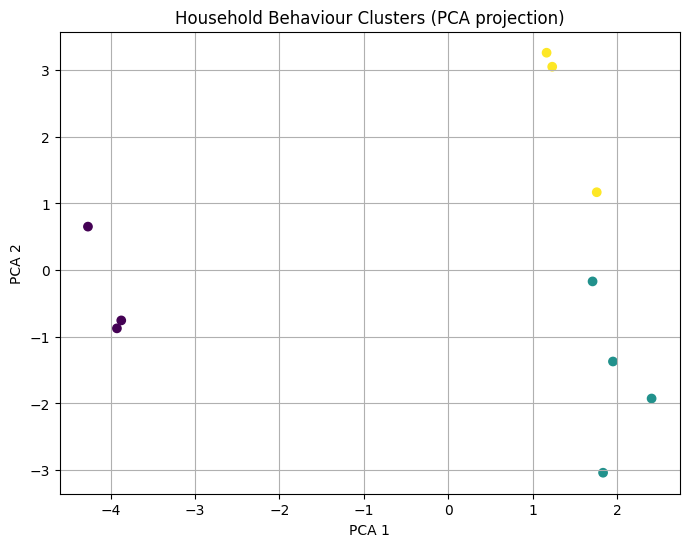

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=features["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Household Behaviour Clusters (PCA projection)")
plt.grid(True)
plt.show()


In [ ]:

cluster_profiles = features.groupby("cluster")[FEATURE_COLS].mean()
display(cluster_profiles)

# Add readable labels 
cluster_labels = {
    0: "Low-consumption households",
    1: "High evening-demand households",
    2: "High overall consumption households"
}

features["cluster_label"] = features["cluster"].map(cluster_labels)
display(features[["household", "cluster", "cluster_label"]])


,total_Wh,mean_Wh,peak_Wh,std_Wh,evening_ratio,weekend_ratio,prod_total_Wh,prod_mean_Wh,prod_peak_Wh,prod_std_Wh,midday_prod_ratio,solar_self_consumption_ratio,grid_dependency_ratio
cluster,,,,,,,,,,,,,
0,6.313800e+06,11.979759,200.640,15.862095,0.380115,0.288489,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.120594
1,4.034259e+06,7.654574,203.055,13.060187,0.381054,0.296970,1.943145e+06,3.686910,81.582500,7.250558,0.643424,0.354627,0.752823
2,7.319154e+06,13.887878,318.610,20.075841,0.364028,0.282449,1.847170e+06,3.504942,78.266667,6.822029,0.635078,0.500910,0.846951


,household,cluster,cluster_label
0,H10_Wh,2,High overall consumption households
1,H11_Wh,2,High overall consumption households
2,H13_Wh,1,High evening-demand households
3,H15_Wh,0,Low-consumption households
4,H1_Wh,1,High evening-demand households
5,H2_Wh,1,High evening-demand households
6,H3_Wh,1,High evening-demand households
7,H4_Wh,2,High overall consumption households
8,H6_Wh,0,Low-consumption households
9,H8_Wh,0,Low-consumption households


In [65]:
import joblib
from pathlib import Path

MODEL_DIR = Path("household_clustering_model")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(kmeans, MODEL_DIR / "kmeans_model.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(FEATURE_COLS, MODEL_DIR / "feature_columns.pkl")

print("Model saved to:", MODEL_DIR)


Model saved to: household_clustering_model


In [ ]:
def assign_new_household(new_df: pd.DataFrame):
    import joblib
    from pathlib import Path
    import numpy as np
    import pandas as pd

    MODEL_DIR = Path("household_clustering_model")

    kmeans = joblib.load(MODEL_DIR / "kmeans_model.pkl")
    scaler = joblib.load(MODEL_DIR / "scaler.pkl")
    feature_cols = joblib.load(MODEL_DIR / "feature_columns.pkl")

    df = new_df.copy()
    df.columns = df.columns.str.strip()

    
    if "household" not in df.columns:
        df["household"] = "NEW_HOUSEHOLD"

    if "date" not in df.columns:
        raise ValueError("Missing required column: date")

   
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])

    
    for col in ["Consumption(Wh)", "Production(Wh)", "From grid(Wh)"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

    
    df["hour"] = df["date"].dt.hour
    df["weekday"] = df["date"].dt.weekday
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)

    
    feats = df.groupby("household")["Consumption(Wh)"].agg(
        total_Wh="sum",
        mean_Wh="mean",
        peak_Wh="max",
        std_Wh="std"
    ).reset_index()
    feats["std_Wh"] = feats["std_Wh"].fillna(0)

    evening = df[(df["hour"] >= 17) & (df["hour"] <= 23)].groupby("household")["Consumption(Wh)"] \
        .sum().reset_index(name="evening_Wh")
    feats = feats.merge(evening, on="household", how="left")
    feats["evening_Wh"] = feats["evening_Wh"].fillna(0)
    feats["evening_ratio"] = feats["evening_Wh"] / (feats["total_Wh"] + 1e-9)

    weekend = df[df["is_weekend"] == 1].groupby("household")["Consumption(Wh)"] \
        .sum().reset_index(name="weekend_Wh")
    feats = feats.merge(weekend, on="household", how="left")
    feats["weekend_Wh"] = feats["weekend_Wh"].fillna(0)
    feats["weekend_ratio"] = feats["weekend_Wh"] / (feats["total_Wh"] + 1e-9)

    # Solar features 
    if "Production(Wh)" in df.columns and "From grid(Wh)" in df.columns:
        df["solar_used_Wh"] = np.minimum(df["Consumption(Wh)"], df["Production(Wh)"])

        solar = df.groupby("household").agg(
            total_consumption=("Consumption(Wh)", "sum"),
            total_production=("Production(Wh)", "sum"),
            grid_import=("From grid(Wh)", "sum"),
            solar_used=("solar_used_Wh", "sum"),
        ).reset_index()

        solar["solar_self_consumption_ratio"] = solar["solar_used"] / (solar["total_production"] + 1e-9)
        solar["grid_dependency_ratio"] = solar["grid_import"] / (solar["total_consumption"] + 1e-9)

        feats = feats.merge(
            solar[["household", "solar_self_consumption_ratio", "grid_dependency_ratio"]],
            on="household",
            how="left"
        )

    
    for c in feature_cols:
        if c not in feats.columns:
            feats[c] = 0  

    X_new = feats[list(feature_cols)].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_new_scaled = scaler.transform(X_new)

    feats["assigned_cluster"] = kmeans.predict(X_new_scaled)
    return feats


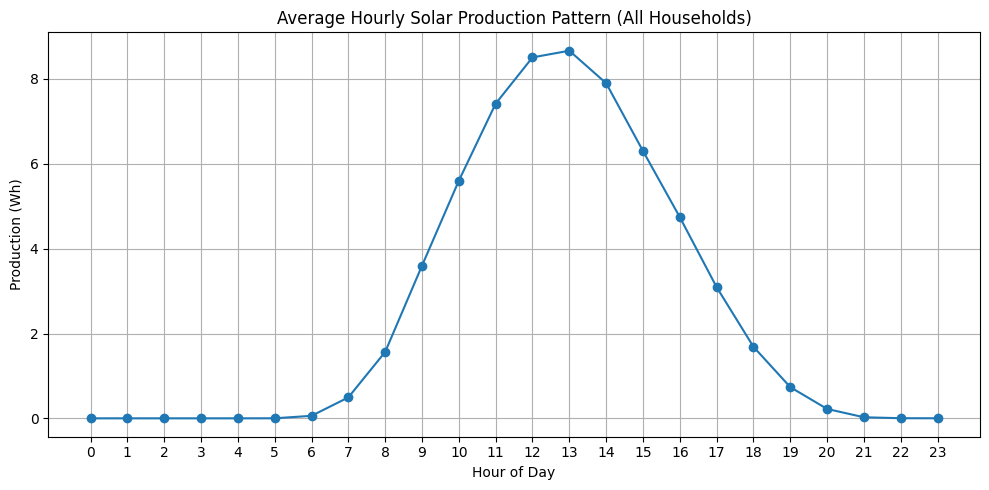

In [67]:
# Average solar production by hour (all households combined)
combined_df["hour"] = combined_df["date"].dt.hour

hourly_prod = combined_df.groupby("hour")["Production(Wh)"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(hourly_prod["hour"], hourly_prod["Production(Wh)"], marker="o")
plt.title("Average Hourly Solar Production Pattern (All Households)")
plt.xlabel("Hour of Day")
plt.ylabel("Production (Wh)")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()


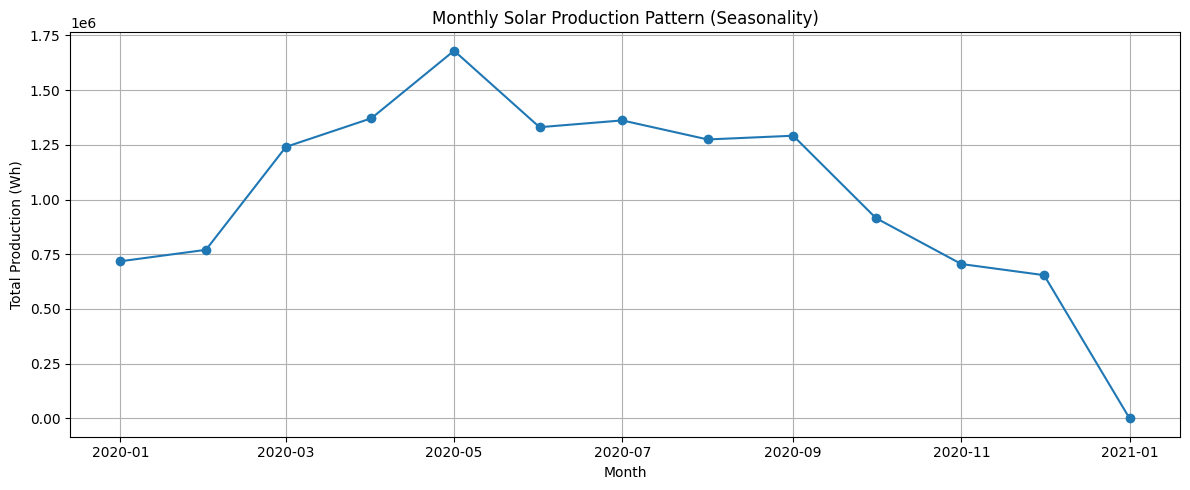

In [68]:
combined_df["month"] = combined_df["date"].dt.to_period("M").dt.to_timestamp()

monthly_prod = combined_df.groupby("month")["Production(Wh)"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_prod["month"], monthly_prod["Production(Wh)"], marker="o")
plt.title("Monthly Solar Production Pattern (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Total Production (Wh)")
plt.grid(True)
plt.tight_layout()
plt.show()


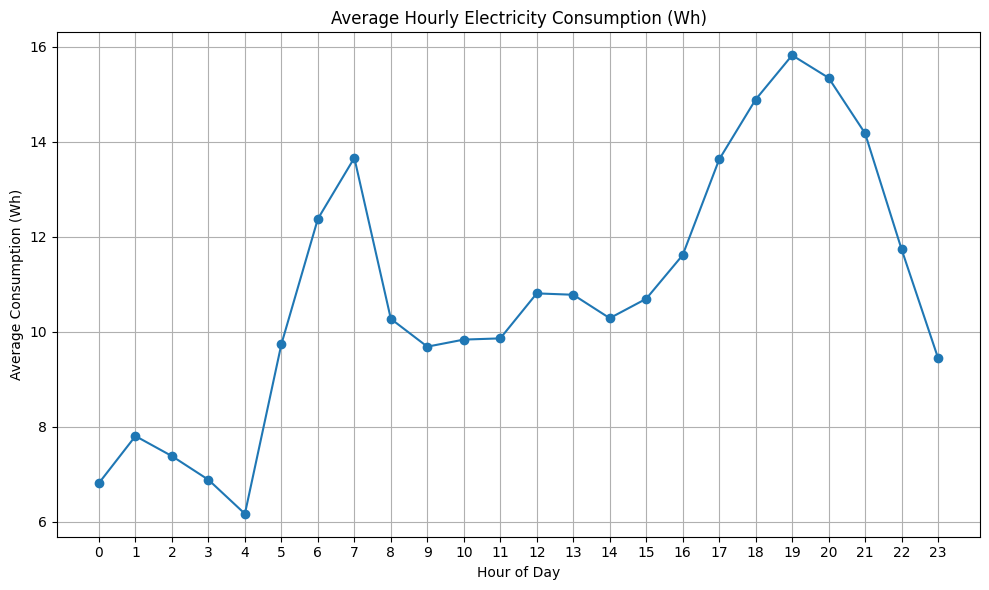

,hour,Consumption(Wh)
0,0,6.820000
1,1,7.807688
2,2,7.385929
3,3,6.888287
4,4,6.172421
5,5,9.739724
6,6,12.376341
7,7,13.658833
8,8,10.273560
9,9,9.688019


In [ ]:
# Deeper analysis: average hourly electricity consumption pattern


combined_df["date"] = pd.to_datetime(combined_df["date"], errors="coerce")


combined_df["hour"] = combined_df["date"].dt.hour


hourly_trend = combined_df.groupby("hour")["Consumption(Wh)"].mean().reset_index()


plt.figure(figsize=(10, 6))
plt.plot(hourly_trend["hour"], hourly_trend["Consumption(Wh)"], marker="o")
plt.title("Average Hourly Electricity Consumption (Wh)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (Wh)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

display(hourly_trend)


In [70]:
cluster_hourly = combined_df.merge(
    features[["household", "cluster"]],
    on="household",
    how="left"
)

cluster_hourly = cluster_hourly.groupby(["cluster", "hour"])["Consumption(Wh)"].mean().reset_index()


In [71]:
combined_df["is_peak"] = combined_df["hour"].between(17, 22)


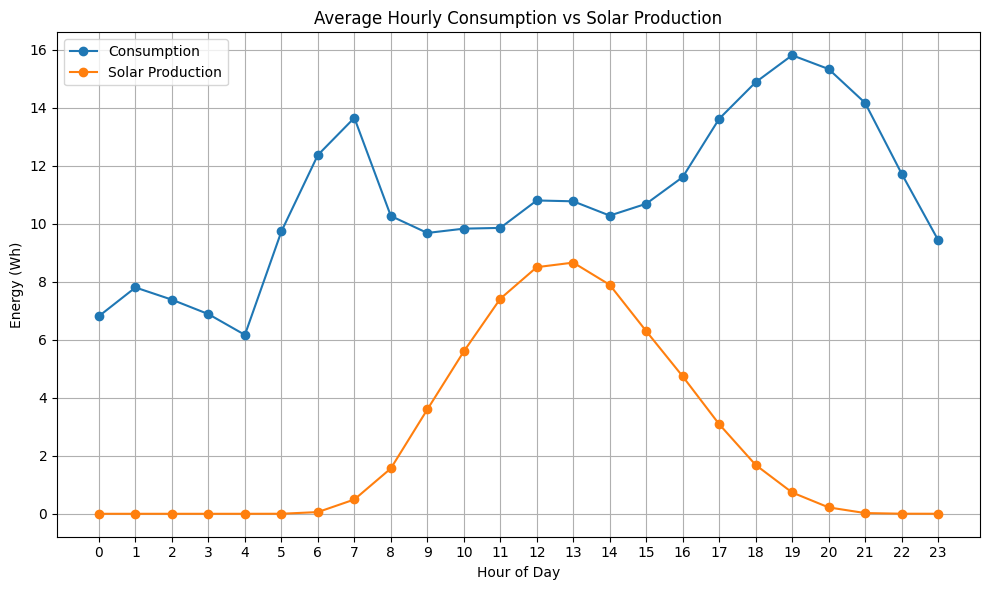

,hour,Consumption(Wh),Production(Wh)
0,0,6.820000,0.000938
1,1,7.807688,0.000942
2,2,7.385929,0.001021
3,3,6.888287,0.000818
4,4,6.172421,0.000923
5,5,9.739724,0.002195
6,6,12.376341,0.059897
7,7,13.658833,0.493970
8,8,10.273560,1.565382
9,9,9.688019,3.598558


In [ ]:
# Solar vs consumption alignment (hourly average)


required_cols = ["Consumption(Wh)", "Production(Wh)", "hour"]
missing = [c for c in required_cols if c not in combined_df.columns]
if missing:
    print("Skipping solar comparison – missing columns:", missing)
else:
    hourly_energy = (
        combined_df
        .groupby("hour")[["Consumption(Wh)", "Production(Wh)"]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 6))
    plt.plot(hourly_energy["hour"], hourly_energy["Consumption(Wh)"], 
             label="Consumption", marker="o")
    plt.plot(hourly_energy["hour"], hourly_energy["Production(Wh)"], 
             label="Solar Production", marker="o")

    plt.title("Average Hourly Consumption vs Solar Production")
    plt.xlabel("Hour of Day")
    plt.ylabel("Energy (Wh)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(hourly_energy)


In [73]:
hourly_energy["solar_offset_ratio"] = (
    hourly_energy["Production(Wh)"] /
    (hourly_energy["Consumption(Wh)"] + 1e-9)
)


In [74]:
cluster_energy = combined_df.merge(
    features[["household", "cluster"]],
    on="household",
    how="left"
)

cluster_hourly = (
    cluster_energy
    .groupby(["cluster", "hour"])[["Consumption(Wh)", "Production(Wh)"]]
    .mean()
    .reset_index()
)


In [ ]:

# Simulating grid usage reduction via demand response



PEAK_START = 17
PEAK_END = 22

combined_df["is_peak"] = combined_df["hour"].between(PEAK_START, PEAK_END)


original_grid = combined_df.groupby("household")["Consumption(Wh)"].sum().reset_index()
original_grid.rename(columns={"Consumption(Wh)": "Original Grid Use(Wh)"}, inplace=True)


peak_consumption = combined_df[combined_df["is_peak"]].groupby("household")["Consumption(Wh)"].sum().reset_index()
peak_consumption.rename(columns={"Consumption(Wh)": "Peak Grid Use(Wh)"}, inplace=True)


grid_summary = original_grid.merge(peak_consumption, on="household", how="left").fillna(0)


grid_summary["Grid Use after 20% Shift"] = grid_summary["Original Grid Use(Wh)"] - 0.20 * grid_summary["Peak Grid Use(Wh)"]
grid_summary["Grid Use after 30% Shift"] = grid_summary["Original Grid Use(Wh)"] - 0.30 * grid_summary["Peak Grid Use(Wh)"]

# Savings
grid_summary["Savings_20% (%)"] = (
    (grid_summary["Original Grid Use(Wh)"] - grid_summary["Grid Use after 20% Shift"])
    / grid_summary["Original Grid Use(Wh)"]
) * 100

grid_summary["Savings_30% (%)"] = (
    (grid_summary["Original Grid Use(Wh)"] - grid_summary["Grid Use after 30% Shift"])
    / grid_summary["Original Grid Use(Wh)"]
) * 100

grid_summary_scaled = grid_summary.copy()

display(grid_summary_scaled)


,household,Original Grid Use(Wh),Peak Grid Use(Wh),Grid Use after 20% Shift,Grid Use after 30% Shift,Savings_20% (%),Savings_30% (%)
0,H10_Wh,7986097.910,2.091295e+06,7.567839e+06,7.358710e+06,5.237338,7.856006
1,H11_Wh,6095938.230,2.608198e+06,5.574299e+06,5.313479e+06,8.557166,12.835749
2,H13_Wh,2770033.190,5.988588e+05,2.650261e+06,2.590376e+06,4.323839,6.485758
3,H15_Wh,5856250.100,2.008386e+06,5.454573e+06,5.253734e+06,6.858948,10.288422
4,H1_Wh,3186876.865,1.780185e+06,2.830840e+06,2.652821e+06,11.171971,16.757957
5,H2_Wh,4885312.005,1.488225e+06,4.587667e+06,4.438845e+06,6.092650,9.138975
6,H3_Wh,5294813.635,1.373339e+06,5.020146e+06,4.882812e+06,5.187489,7.781233
7,H4_Wh,7875426.460,2.333424e+06,7.408742e+06,7.175399e+06,5.925836,8.888754
8,H6_Wh,6261265.275,2.977105e+06,5.665844e+06,5.368134e+06,9.509594,14.264391
9,H8_Wh,6823884.565,1.535364e+06,6.516812e+06,6.363275e+06,4.499970,6.749956


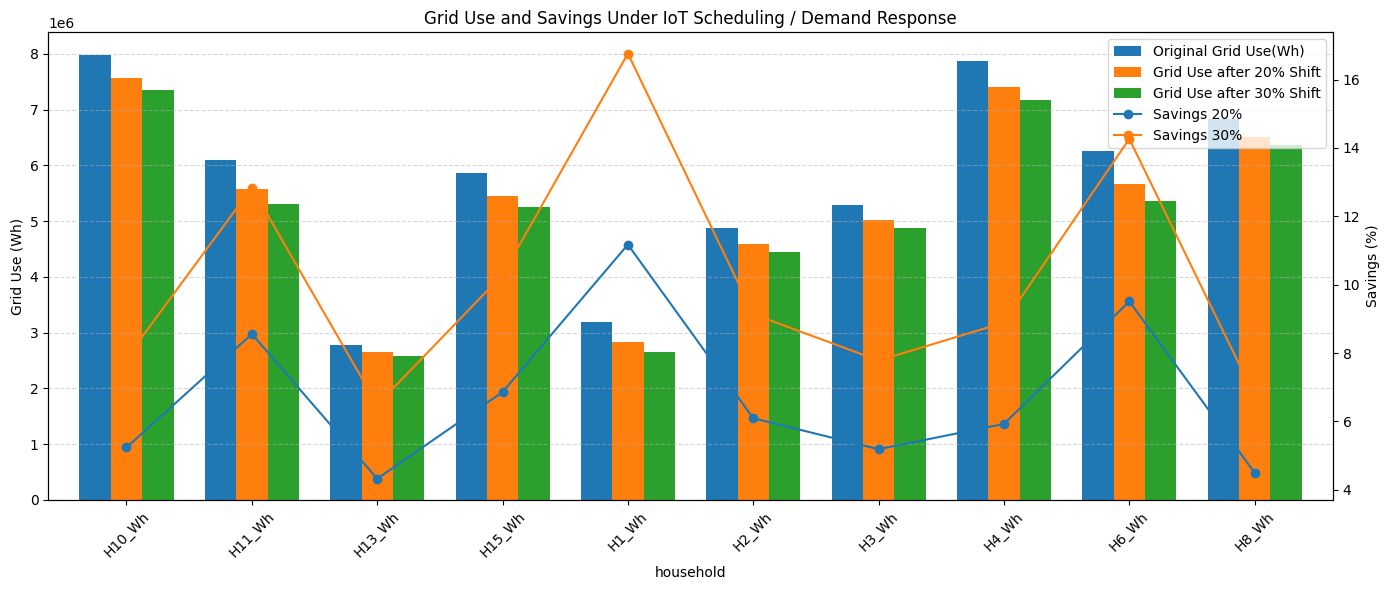

In [ ]:
# Visualize grid_summary_scaled (grid use + savings)

households_data = grid_summary_scaled.copy()


if "household" in households_data.columns:
    households_data = households_data.set_index("household")

needed_cols = [
    "Original Grid Use(Wh)",
    "Grid Use after 20% Shift",
    "Grid Use after 30% Shift",
    "Savings_20% (%)",
    "Savings_30% (%)"
]

missing = [c for c in needed_cols if c not in households_data.columns]
if missing:
    print("Cannot plot grid_summary_scaled. Missing columns:", missing)
else:
    fig, ax1 = plt.subplots(figsize=(14, 6))

    
    households_data[[
        "Original Grid Use(Wh)",
        "Grid Use after 20% Shift",
        "Grid Use after 30% Shift"
    ]].plot(kind="bar", ax=ax1, width=0.75)

    ax1.set_ylabel("Grid Use (Wh)")
    ax1.set_title("Grid Use and Savings Under IoT Scheduling / Demand Response")
    ax1.tick_params(axis="x", rotation=45)
    ax1.grid(True, axis="y", linestyle="--", alpha=0.5)

   
    ax2 = ax1.twinx()
    ax2.plot(households_data.index, households_data["Savings_20% (%)"], marker="o", label="Savings 20%")
    ax2.plot(households_data.index, households_data["Savings_30% (%)"], marker="o", label="Savings 30%")
    ax2.set_ylabel("Savings (%)")

   
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")

    plt.tight_layout()
    plt.show()
